# 1번 - ResNet 모델을 불러와 새로운 이미지 데이터셋을 분류하세요

In [ ]:
import numpy as np

# 딥러닝 프레임워크. tf.image.resize() 같은 이미지 처리 함수를 쓰기 위해 임포트
import tensorflow as tf

# Keras가 제공하는 사전훈련 모델 모음에서 ResNet50 가져오는 코드
from tensorflow.keras.applications import ResNet50

# 레이어를 순서대로 쌓는 모델 구조
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical



```
import tensorflow as tf
```
- 딥러닝 프레임워크. tf.image.resize() 같은 이미지 처리 함수를 쓰기 위해 임포트


```
from tensorflow.keras.applications import ResNet50
```

- Keras가 제공하는 사전훈련 모델 모음에서 ResNet50 가져오는 코드 ( ResNet50은 ImageNet 100만 장으로 이미 학습된 모델 )

- weights='imagenet'으로 불러오면 100만 장으로 학습된 가중치를 그대로 사용할 수 있음


```
from tensorflow.keras.models import Sequential
```
- 레이어를 순서대로 쌓는 모델 구조

- model.add(레이어) 형식으로 위에서 아래로 쌓아가는 방식

```
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
```
- Dense : 완전 연결층. 모든 뉴런이 다음 층의 모든 뉴런과 연결되는 기본 층

- GlobalAveragePooling2D : 2D 특징 맵을 받아서 각 채널의 평균값 하나씩만 뽑아내는 층. 3D → 1D로 압축해 줌


```
from tensorflow.keras.optimizers import Adam
```
- 가중치를 어떻게 업데이트할지 결정하는 최적화 알고리즘

- Adam: 학습률을 자동으로 조절해줘서 가장 많이 쓰임


```
from tensorflow.keras.datasets import cifar10
```
- Keras에 내장된 CIFAR-10 데이터셋 ( 비행기·자동차·새 등 10개 클래스, 총 60000장짜리 이미지 데이터 )


```
from tensorflow.keras.utils import to_categorical
```
- 정수 레이블 → 원-핫 인코딩으로 바꿔주는 함수



>  예시: 3 → [0,0,0,1,0,0,0,0,0,0] 이렇게 변환 됨





In [ ]:
# CIFAR-10 데이터셋 로드 및 전처리
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step


In [ ]:
# 1. 먼저 자르고
x_train = x_train[:5000]
y_train = y_train[:5000]

# 2. 그 다음 resize
# .numpy() : TensorFlow 텐서 형식 → NumPy 배열로 변환 ( Keras가 NumPy 배열을 받기 때문에 필요 )
# / 255.0 : 픽셀값 0~255를 0.0~1.0으로 정규화 ( 값이 크면 학습이 불안정해지기 때문 )
x_train = tf.image.resize(x_train, (64, 64)).numpy() / 255.0
x_test  = tf.image.resize(x_test,  (64, 64)).numpy() / 255.0

# 3. 원-핫 인코딩으로 변환 ( categorical_crossentropy 손실함수가 이 형식을 요구함 )
num_classes = 10  # CIFAR-10은 10개 클래스니까 10
y_train = to_categorical(y_train, num_classes)
y_test  = to_categorical(y_test,  num_classes)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: (5000, 64, 64, 3)
y_train shape: (5000, 10)


50000장 전부 썼더니 메모리 부족으로 세션이 다운되어서 resize 전에 5000장으로 자르는 작업을 거쳤음

In [ ]:
# 사전 훈련된 ResNet50 로드 (ImageNet 가중치, 상단 FC층 제외)
base_model = ResNet50(
    weights='imagenet',      # ImageNet으로 사전훈련된 가중치를 그대로 불러옴 ( 만약에 None이면 가중치 없이 구조만 가져옴 )
    include_top=False,       # 원래 분류층(1000개 클래스) 제외
    input_shape=(64, 64, 3)
)
base_model.trainable = False  # 사전훈련 가중치 동결 (특징 추출기로만 사용)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 새로운 분류 모델 구축
model = Sequential([
    base_model, # ResNet50 특징 추출기. 이미지에서 특징을 뽑아줌
    GlobalAveragePooling2D(), # (7, 7, 2048) → (2048,) 로 압축 ( 각 채널(2048개)의 7×7 값들을 평균낸 것 )
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 2, 2, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## include_top=False 란?

ResNet50은 원래 ImageNet(1000개 클래스)을 분류하기 위해 만들어진 모델

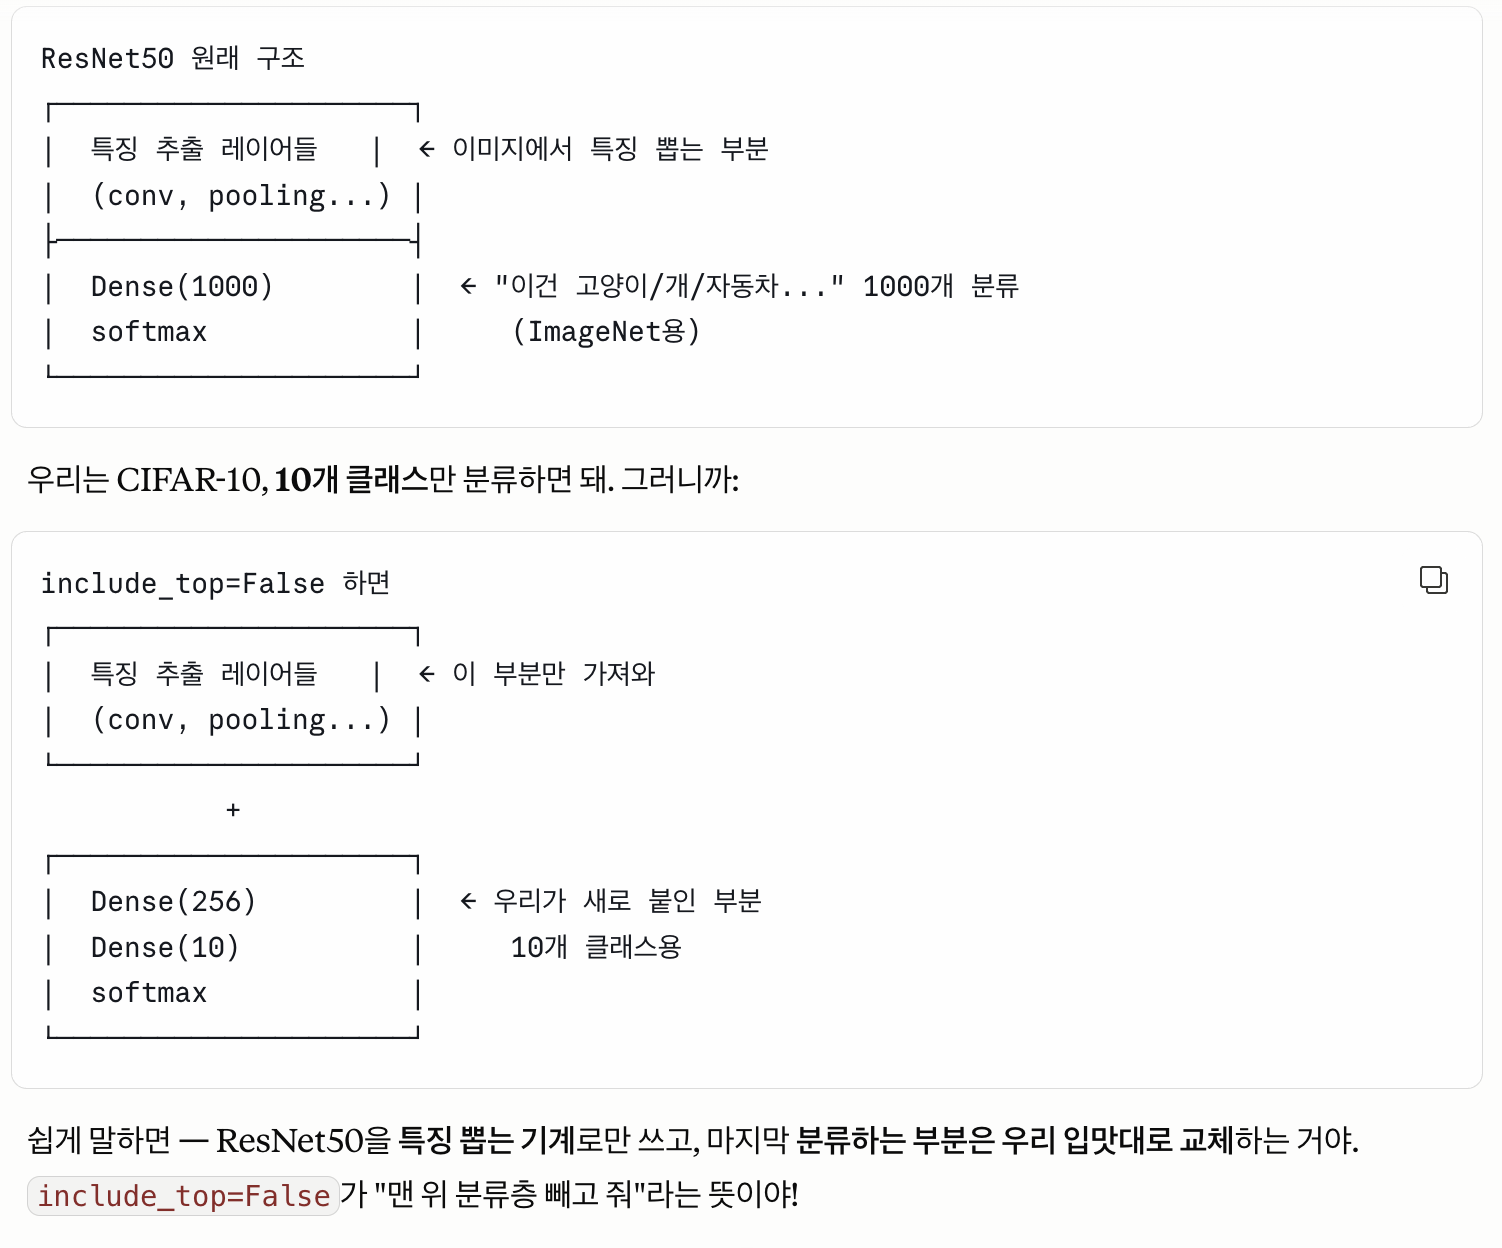

In [ ]:
# 모델 컴파일
model.compile(
    optimizer=Adam(learning_rate=0.0001), # 가중치 업데이트 방식. learning_rate는 한 번에 얼마나 크게 업데이트할지 조절함 ( 너무 크면 학습이 튀고, 너무 작으면 느림 )
    loss='categorical_crossentropy',  # 손실함수 ( 원-핫 인코딩 레이블과 모델 출력(확률)의 차이를 계산 ) <- 이 값이 작아지게 학습
    metrics=['accuracy']
)

In [ ]:
# 모델 훈련
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,  # 한 번에 32장씩 묶어서 처리
    validation_split=0.1  # 훈련 데이터의 10%(5000장)를 검증용으로 분리. 학습 중 과적합 여부를 모니터링
)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 101s 651ms/step - accuracy: 0.1089 - loss: 2.3098 - val_accuracy: 0.1040 - val_loss: 2.2853
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 104s 738ms/step - accuracy: 0.1576 - loss: 2.2771 - val_accuracy: 0.1860 - val_loss: 2.2707
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 109s 766ms/step - accuracy: 0.1753 - loss: 2.2581 - val_accuracy: 0.1880 - val_loss: 2.2500
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 85s 604ms/step - accuracy: 0.1982 - loss: 2.2421 - val_accuracy: 0.2000 - val_loss: 2.2359
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 149s 650ms/step - accuracy: 0.2160 - loss: 2.2237 - val_accuracy: 0.2380 - val_loss: 2.2201
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 86s 609ms/step - accuracy: 0.2180 - loss: 2.2084 - val_accuracy: 0.2540 - val_loss: 2.2049
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 141s 603ms/step - accuracy: 0.2498 - loss: 2.1908 - val_accuracy: 0.2200 - val_loss: 2.1906
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 82s 583ms/step - accuracy: 0.2427 - lo

In [ ]:
# 모델 평가
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 167s 535ms/step - accuracy: 0.2643 - loss: 2.1424
Test Loss:     2.1424
Test Accuracy: 0.2643


# 2번 - 이미지 데이터셋과 사전 훈련된 VGG16 모델을 가져와 전이 학습을 수행하세요

In [ ]:
# ✅ 1. 라이브러리 임포트
import numpy as np
import tensorflow as tf

# Keras 사전훈련 모델 모음에서 VGG16을 가져온다. ( 1번에서 ResNet50 대신 VGG16으로 바뀐 것 )
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential

# Dense : 완전 연결층. 1번이랑 동일
# Flatten : 다차원 배열을 1차원으로 펼치는 층
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [ ]:
# 2. CIFAR-10 데이터셋 로드 및 전처리 ( 1번과 동일 )
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 1. 먼저 자르고
x_train = x_train[:5000]
y_train = y_train[:5000]

# 2. 그 다음 resize
x_train = tf.image.resize(x_train, (64, 64)).numpy() / 255.0
x_test  = tf.image.resize(x_test,  (64, 64)).numpy() / 255.0

# 3. 마지막에 원-핫 인코딩
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test  = to_categorical(y_test,  num_classes)

In [ ]:
# 3. 사전 훈련된 VGG16 로드 ( 1번 ResNet50이랑 구조가 똑같음. 모델 이름만 바뀐 것 )
base_model = VGG16(
    weights='imagenet', # ImageNet 사전훈련 가중치 사용
    include_top=False,  # 원래 1000개 클래스 분류층 제외
    input_shape=(64, 64, 3) # 64×64 RGB 이미지
)
base_model.trainable = False  # VGG16 사전훈련 가중치 동결 ( 이 줄 없으면 ImageNet 가중치가 우리 데이터로 덮어씌워짐 )

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# ✅ 4. 새로운 분류 모델 구축
model = Sequential([
    base_model, # VGG16 특징 추출기
    Flatten(),  # (2, 2, 512) → (2048,) 로 펼쳐줌 ( 1번의 GlobalAveragePooling2D랑 같은 역할인데 방식이 다름 )
    Dense(256, activation='relu'),  # 2048개 → 256개 뉴런으로 압축
    Dense(num_classes, activation='softmax')  # 256개 → 10개 확률 출력
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 2, 2, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,241,802 (58.14 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Flatten vs GlobalAveragePooling2D 차이


```
(2, 2, 512) 입력 기준

Flatten             GlobalAveragePooling2D
모든 값을 그냥 펼침    채널별 평균값 하나씩만 뽑음
2×2×512 = 2048개    512개
정보 전부 유지        정보 압축
파라미터 많아짐        파라미터 적어짐
```



In [ ]:
# 5. 모델 컴파일 ( 1번과 동일 )
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 6. 모델 훈련 ( 1번과 동일 )
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 262s 2s/step - accuracy: 0.3524 - loss: 1.9410 - val_accuracy: 0.4360 - val_loss: 1.7270
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 274s 2s/step - accuracy: 0.5253 - loss: 1.4866 - val_accuracy: 0.4860 - val_loss: 1.5387
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.5793 - loss: 1.3038 - val_accuracy: 0.5320 - val_loss: 1.4054
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - accuracy: 0.6198 - loss: 1.1860 - val_accuracy: 0.5220 - val_loss: 1.3352
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.6493 - loss: 1.1001 - val_accuracy: 0.5600 - val_loss: 1.2792
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.6720 - loss: 1.0363 - val_accuracy: 0.5640 - val_loss: 1.2424
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 270s 2s/step - accuracy: 0.6873 - loss: 0.9814 - val_accuracy: 0.5720 - val_loss: 1.2190
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.7071 - loss: 0.9271 - val_accu

In [ ]:
# 7. 모델 평가 ( 1번과 동일 )
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss:     {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 519s 2s/step - accuracy: 0.6160 - loss: 1.1295
Test Loss:     1.1295
Test Accuracy: 0.6160


# 3번 - 동일한 데이터셋에서 ResNet과 VGG16을 각각 학습시켜 성능을 비교하세요

In [ ]:
# 1. 라이브러리 임포트
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt # 그래프를 그리는 라이브러리

# 1번에선 ResNet50만, 2번에선 VGG16만 가져왔는데, 3번은 둘 다
from tensorflow.keras.applications import ResNet50, VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

In [ ]:
# 2. 데이터 로드 및 전처리 ( 1,2번과 동일 )
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 1. 먼저 자르고
x_train = x_train[:5000]
y_train = y_train[:5000]

# 2. resize
x_train = tf.image.resize(x_train, (64, 64)).numpy() / 255.0
x_test  = tf.image.resize(x_test,  (64, 64)).numpy() / 255.0

# 3. 원-핫 인코딩
num_classes = 10
y_train = to_categorical(y_train, num_classes)
y_test  = to_categorical(y_test,  num_classes)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
# 3. ResNet50 모델 구축 ( 1번과 동일, 변수명만 바뀜 (두가지 모델을 쓰기때문에 구분하기 위해서) )
resnet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)
resnet_base.trainable = False

resnet_model = Sequential([
    resnet_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

resnet_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 4. VGG16 모델 구축 ( 2번과 동일 (동일한 이유로 변수만 다름))
vgg_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(64, 64, 3)
)
vgg_base.trainable = False

vgg_model = Sequential([
    vgg_base,
    Flatten(),
    Dense(256, activation='relu'),
    Dense(num_classes, activation='softmax')
])

vgg_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 5. 두 모델 훈련
print("=== ResNet50 훈련 ===")
history_resnet = resnet_model.fit(  # 두 모델의 학습 기록을 따로 저장 ( 이후 비교를 위해서, 같은 이름 쓰면 덮히니까 )
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

print("=== VGG16 훈련 ===")
history_vgg = vgg_model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

=== ResNet50 훈련 ===
Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 85s 539ms/step - accuracy: 0.1118 - loss: 2.3108 - val_accuracy: 0.1200 - val_loss: 2.2773
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 76s 538ms/step - accuracy: 0.1496 - loss: 2.2702 - val_accuracy: 0.1320 - val_loss: 2.2595
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 72s 507ms/step - accuracy: 0.1813 - loss: 2.2470 - val_accuracy: 0.1260 - val_loss: 2.2419
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 85s 534ms/step - accuracy: 0.2020 - loss: 2.2269 - val_accuracy: 0.1620 - val_loss: 2.2226
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 71s 507ms/step - accuracy: 0.2167 - loss: 2.2041 - val_accuracy: 0.2360 - val_loss: 2.2010
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 83s 515ms/step - accuracy: 0.2256 - loss: 2.1857 - val_accuracy: 0.2180 - val_loss: 2.1800
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 81s 509ms/step - accuracy: 0.2400 - loss: 2.1652 - val_accuracy: 0.2200 - val_loss: 2.1625
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 75s 531ms/step - accura

In [ ]:
# 6. 두 모델 평가
# 각 모델을 테스트 데이터로 평가해서 loss와 accuracy를 따로 변수에 저장
resnet_loss, resnet_acc = resnet_model.evaluate(x_test, y_test)
vgg_loss, vgg_acc = vgg_model.evaluate(x_test, y_test)

print(f"\nResNet50 - Test Loss: {resnet_loss:.4f} / Test Accuracy: {resnet_acc:.4f}")
print(f"VGG16    - Test Loss: {vgg_loss:.4f} / Test Accuracy: {vgg_acc:.4f}")

if resnet_acc > vgg_acc:
    print("\n✅ ResNet50의 정확도가 더 높습니다.")
else:
    print("\n✅ VGG16의 정확도가 더 높습니다.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 146s 466ms/step - accuracy: 0.2707 - loss: 2.1135
313/313 ━━━━━━━━━━━━━━━━━━━━ 468s 1s/step - accuracy: 0.6120 - loss: 1.1400

ResNet50 - Test Loss: 2.1135 / Test Accuracy: 0.2707
VGG16    - Test Loss: 1.1400 / Test Accuracy: 0.6120

✅ VGG16의 정확도가 더 높습니다.


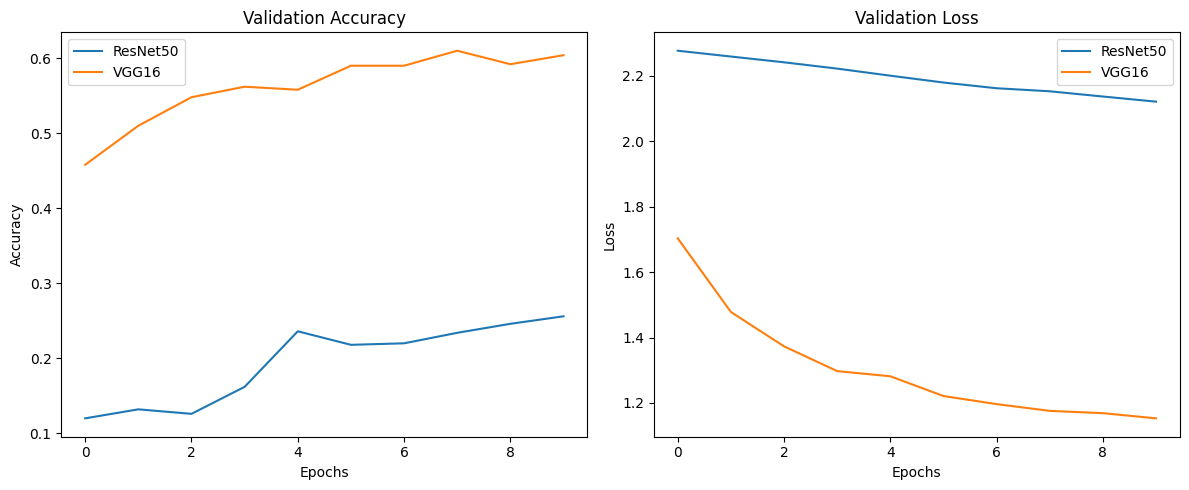

In [ ]:
# ✅ 7. 성능 시각화
plt.figure(figsize=(12, 5))

# 정확도 그래프
plt.subplot(1, 2, 1)
plt.plot(history_resnet.history['val_accuracy'], label='ResNet50')
plt.plot(history_vgg.history['val_accuracy'],    label='VGG16')
plt.title('Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 손실 그래프
plt.subplot(1, 2, 2)
plt.plot(history_resnet.history['val_loss'], label='ResNet50')
plt.plot(history_vgg.history['val_loss'],    label='VGG16')
plt.title('Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 4번 - 가상 데이터셋을 생성한 뒤, GridSearch와 RandomSearch 기법으로 하이퍼파라미터 튜닝을 진행하세요

In [ ]:
# 1. 라이브러리 임포트
import numpy as np

# 사이킷런에서 제공하는 가상 데이터 생성 함수 ( 이미지가 아니라 숫자 특징(feature) 기반의 분류용 데이터를 만들어줌 )
from sklearn.datasets import make_classification

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# 사이킷런의 랜덤 포레스트 모델 ( 여러 개의 결정 트리를 만들고 그 결과를 합쳐서 예측하는 머신러닝 모델 )
from sklearn.ensemble import RandomForestClassifier

# RandomSearch에서 하이퍼파라미터를 무작위로 뽑을 범위를 정의할 때 쓰는 함수
from scipy.stats import randint



```
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
```
* train_test_split : 데이터를 훈련/테스트로 나눠주는 함수
* GridSearchCV : 모든 하이퍼파라미터 조합을 다 시도하는 GridSearch 클래스
* RandomizedSearchCV : 무작위로 일부 조합만 시도하는 RandomSearch 클래스


In [ ]:
# ✅ 2. 가상 데이터셋 생성
X, y = make_classification(
    n_samples=1000,   # 데이터 샘플 1000개 생성
    n_features=20,    # 각 샘플이 20개의 특징(feature)을 가짐
    n_informative=2,  # 20개 특징 중 실제로 분류에 유용한 특징은 2개
    n_redundant=10,   # 20개 특징 중 유용한 특징들의 조합으로 만들어진 특징이 10개
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  # 전체 1000개 중 20%(200개)를 테스트용으로 분리 ( 80%는 훈련용 )
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (800, 20)
X_test shape:  (200, 20)


In [ ]:
# 3. GridSearch ( GridSearch가 시도할 하이퍼파라미터 조합을 딕셔너리로 정의해줌, 총 3×3×3 = 27가지 조합을 전부 시도 )
param_grid = {
    'n_estimators': [50, 100, 200], # 랜덤 포레스트에서 만들 결정 트리의 수 (50, 100, 200 -> 3가지 )
    'max_depth': [10, 20, 30],      # 각 트리의 최대 깊이 (10, 20, 30 -> 3가지)
    'min_samples_split': [2, 5, 10] # 노드를 나누기 위한 최소 샘플 수 (2, 5, 10 -> 3가지)
}

# GridSearch에 넘겨줄 랜덤 포레스트 모델을 만듦 ( 만들때 하이퍼파라미터 설정 X -> GridSearch가 알아서 바꿔가면서 시도할거기 때문에 )
grid_model = RandomForestClassifier(random_state=42)

# GridSearch 설정
grid_search = GridSearchCV(
    estimator=grid_model,   # 어떤 모델로 탐색할지 지정
    param_grid=param_grid,  # 위에서 정의한 27가지 조합을 넘겨줌
    cv=5, # 각 조합을 5-폴드 교차 검증으로 평가 (데이터를 5등분해서 4개로 훈련, 1개로 검증하는 걸 5번 반복하는 것)
    scoring='accuracy'  # 정확도를 기준으로 최적 조합을 선택
)

# 27가지 조합 × 5-폴드 = 135번 훈련을 돌림
grid_search.fit(X_train, y_train)

# best_params_ : GridSearch가 찾은 최적 하이퍼파라미터 조합을 출력
print("\n=== GridSearch 결과 ===")
print("Best Parameters:", grid_search.best_params_)
# best_estimator_ : 최적 하이퍼파라미터로 이미 학습된 모델을 가져옴 (다시 학습할 필요X)
grid_best = grid_search.best_estimator_
print(f"Train Accuracy: {grid_best.score(X_train, y_train):.4f}") # score() : 주어진 데이터에 대한 정확도를 계산
print(f"Test Accuracy:  {grid_best.score(X_test, y_test):.4f}")


=== GridSearch 결과 ===
Best Parameters: {'max_depth': 20, 'min_samples_split': 10, 'n_estimators': 100}
Train Accuracy: 0.9637
Test Accuracy:  0.9250


In [ ]:
# 4. RandomSearch
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(10, 30),
    'min_samples_split': randint(2, 10)
}

# RandomSearch용 모델
random_model = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=random_model,
    param_distributions=param_dist, # GridSearch의 param_grid 자리로 범위로 정의된 분포를 넘겨 줌
    n_iter=20,  # 전체 조합 중 20가지만 무작위로 뽑아서 시도 (GridSearch는 전부 다 하지만 RandomSearch는 이 숫자만큼만)
    cv=5,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train, y_train)

print("\n=== RandomSearch 결과 ===")
print("Best Parameters:", random_search.best_params_)

random_best = random_search.best_estimator_
print(f"Train Accuracy: {random_best.score(X_train, y_train):.4f}")
print(f"Test Accuracy:  {random_best.score(X_test, y_test):.4f}")


=== RandomSearch 결과 ===
Best Parameters: {'max_depth': 19, 'min_samples_split': 9, 'n_estimators': 64}
Train Accuracy: 0.9663
Test Accuracy:  0.9200




```
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(10, 30),
    'min_samples_split': randint(2, 10)
}
```
**GridSearch의 param_grid랑 비슷한데 방식이 다름**
* GridSearch : [50, 100, 200] → 딱 지정한 값들만 시도
* RandomSearch : randint(50, 200) → 50~200 사이 어떤 값이든 무작위로 뽑아서 시도



In [ ]:
# ✅ 5. 두 방법 비교
print("\n=== 최종 비교 ===")
print(f"GridSearch   Best Test Accuracy: {grid_best.score(X_test, y_test):.4f}")
print(f"RandomSearch Best Test Accuracy: {random_best.score(X_test, y_test):.4f}")


=== 최종 비교 ===
GridSearch   Best Test Accuracy: 0.9250
RandomSearch Best Test Accuracy: 0.9200
